In [2]:
import random
import matplotlib.pyplot as plt
import math



In [3]:
def simulate_martingale(total_bets=100, initial_wallet=100, initial_bet=1):
    # Configuration
    payoff_multiplier = 1 # 1:1 payout for heads/tails
    wallet = initial_wallet
    current_bet = initial_bet
    
    # 0 = Heads, 1 = Tails
    # We start with Heads (0)
    current_side = 'Heads' 
    
    # Data storage for plotting
    wallet_history = [wallet] # Record starting amount
    payoffs = []
    bet_indices = list(range(1, total_bets + 1))
    
    print(f"{'Run':<5} | {'Side':<6} | {'Bet':<5} | {'Outcome':<8} | {'Payoff':<6} | {'Wallet':<6}")
    print("-" * 60)

    for i in range(total_bets):
        # Stop if we are broke
        if wallet <= 0:
            payoffs.append(0)
            wallet_history.append(0)
            continue

        # Rule: If required bet is larger than wallet, bet everything remaining (All-in)
        if current_bet > wallet:
            actual_bet = wallet
        else:
            actual_bet = current_bet

        # Flip Coin: Random choice
        coin_flip = random.choice(['Heads', 'Tails'])
        
        # Check Win or Loss
        if current_side == coin_flip:
            # --- WIN ---
            payoff = actual_bet*payoff_multiplier
            wallet += payoff
            
            # Logic: Reset bet to $1 and Switch Sides
            current_bet = initial_bet
            current_side = 'Tails' if current_side == 'Heads' else 'Heads'
            result_str = "WIN"
        else:
            # --- LOSE ---
            payoff = -actual_bet
            wallet += payoff # (Adding a negative number)
            
            # Logic: Double the bet, Stay on same side
            current_bet = actual_bet * 2
            # current_side remains the same
            result_str = "LOSS"

        # Record data
        payoffs.append(payoff)
        wallet_history.append(wallet)

        # Optional: Print text log for first few and last few to avoid clutter
        if i < 10 or i > total_bets - 5 or wallet == 0:
             print(f"{i+1:<5} | {current_side:<6} | {actual_bet:<5} | {result_str:<8} | {payoff:<6} | {wallet:<6}")

    return bet_indices, payoffs, wallet_history



Run   | Side   | Bet   | Outcome  | Payoff | Wallet
------------------------------------------------------------
1     | Heads  | 1     | LOSS     | -1     | 99    
2     | Tails  | 2     | WIN      | 2      | 101   
3     | Tails  | 1     | LOSS     | -1     | 100   
4     | Heads  | 2     | WIN      | 2      | 102   
5     | Heads  | 1     | LOSS     | -1     | 101   
6     | Tails  | 2     | WIN      | 2      | 103   
7     | Heads  | 1     | WIN      | 1      | 104   
8     | Tails  | 1     | WIN      | 1      | 105   
9     | Tails  | 1     | LOSS     | -1     | 104   
10    | Tails  | 2     | LOSS     | -2     | 102   
41    | Tails  | 54    | LOSS     | -54    | 0     


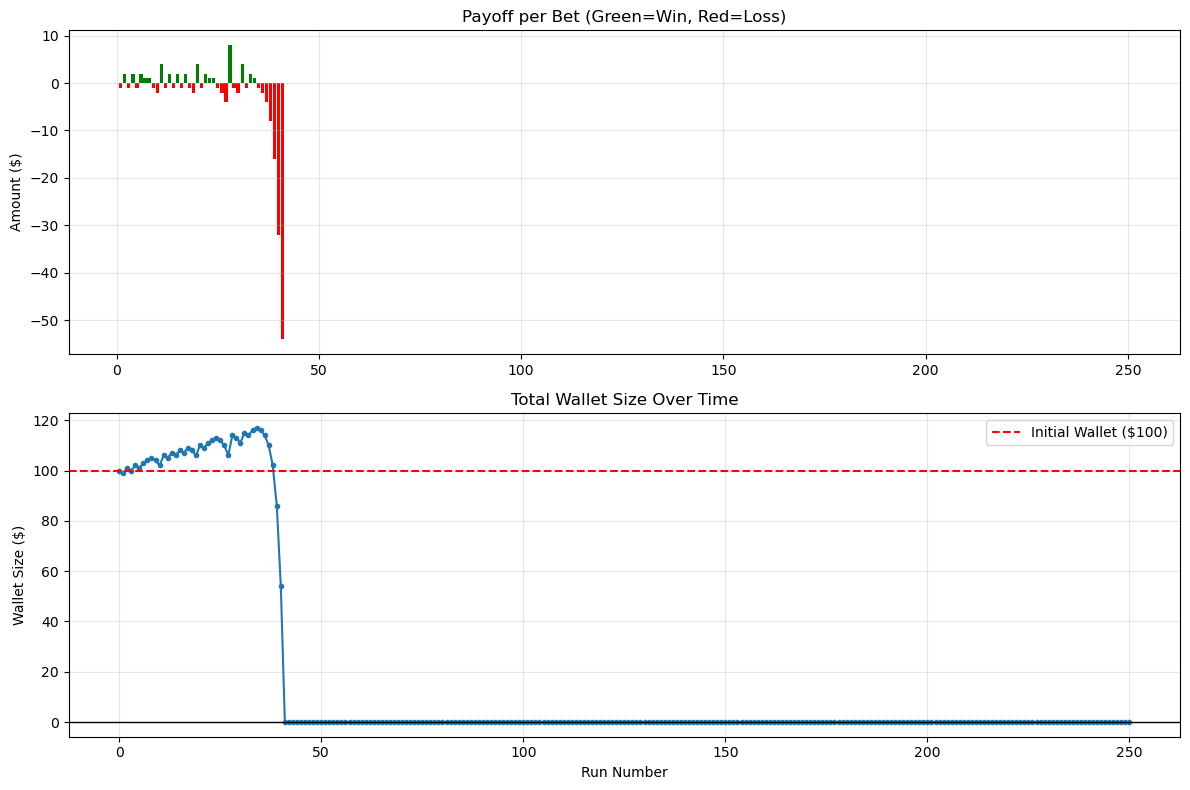

In [4]:
# --- Execution ---
total_bets=250
initial_wallet=100
initial_bet=1  # Starting bet as log2 of initial wallet

runs, payoffs, wallet_data = simulate_martingale(total_bets, initial_wallet, initial_bet)

# --- Plotting ---
plt.figure(figsize=(12, 8))

# Plot 1: Payoffs per Bet
plt.subplot(2, 1, 1)
colors = ['green' if p > 0 else 'red' for p in payoffs]
plt.bar(runs, payoffs, color=colors)
plt.title('Payoff per Bet (Green=Win, Red=Loss)')
plt.ylabel('Amount ($)')
plt.grid(True, alpha=0.3)

# Plot 2: Total Wallet Size
plt.subplot(2, 1, 2)
plt.plot(range(0, len(wallet_data)), wallet_data, marker='o', linestyle='-', markersize=3)
plt.axhline(y=initial_wallet, color='r', linestyle='--', label=f'Initial Wallet (${initial_wallet})')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Total Wallet Size Over Time')
plt.xlabel('Run Number')
plt.ylabel('Wallet Size ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()